In [1]:
!pip install git+https://github.com/amazon-science/chronos-forecasting.git -q
!pip install statsmodels scikit-learn matplotlib gluonts torch -q
!pip install pytorch-forecasting

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 47.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.3/425.3 kB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 70.8 MB/s eta 0:00:00


In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.forecasting.theta import ThetaModel
from chronos import ChronosPipeline
from datasets import load_dataset
import torch
import warnings
warnings.filterwarnings('ignore')

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [4]:
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map=device,
    torch_dtype=torch.float32,
)

config.json:   0%|          | 0.00/1.11k [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/185M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

In [5]:
def smape(actual, forecast):
    return 100 * np.mean(2 * np.abs(actual - forecast) / (np.abs(actual) + np.abs(forecast) + 1e-8))

def seasonal_naive(series, seasonality, prediction_length):
    if len(series) < seasonality:
        return np.full(prediction_length, series[-1] if len(series) > 0 else 0)
    last_season = series[-seasonality:]
    forecast = np.tile(last_season, (prediction_length // seasonality + 1))[:prediction_length]
    return forecast

In [6]:
def ets_forecast(series, prediction_length, seasonality):
    try:
        if len(series) > 2 * seasonality:
            model = ExponentialSmoothing(series, seasonal_periods=seasonality, trend=None, seasonal='add')
            fit = model.fit()
            return fit.forecast(prediction_length)
        else:
            return None
    except:
        return None

def arima_forecast(series, prediction_length):
    try:
        if len(series) > 50:
            model = ARIMA(series, order=(5,1,0))
            fit = model.fit()
            return fit.forecast(prediction_length)
        else:
            return None
    except:
        return None

def theta_forecast(series, prediction_length, seasonality):
    try:
        if len(series) > 2 * seasonality:
            model = ThetaModel(series, period=seasonality)
            fit = model.fit()
            return fit.forecast(prediction_length)
        else:
            return None
    except:
        return None

In [8]:
def evaluate_models_on_dataset(dataset_name, display_name, prediction_length, seasonality, max_series=None):
    print(f"Горизонт: {prediction_length}, Сезонность: {seasonality}")

    dataset = load_dataset("autogluon/chronos_datasets", dataset_name, split="train")
    df = dataset.to_pandas()

    series_ids = df['id'].unique()
    n_series_total = len(series_ids)

    if max_series is None:
        n_series = n_series_total
        series_ids = series_ids
    else:
        n_series = min(max_series, n_series_total)
        series_ids = series_ids[:n_series]

    print(f"Всего рядов в датасете: {n_series_total}")
    print(f"Будет обработано: {n_series}")

    chronos_results = []
    snaive_results = []
    ets_results = []
    arima_results = []
    theta_results = []

    for idx, series_id in enumerate(series_ids):
        series_data = df[df['id'] == series_id]['target'].values[0]

        if not isinstance(series_data, np.ndarray):
            series_data = np.array(series_data)

        if len(series_data) < prediction_length + 50:
            continue

        train = series_data[:-prediction_length]
        test = series_data[-prediction_length:]

        # --- Chronos ---
        forecast = pipeline.predict(
            torch.tensor(train, dtype=torch.float32),
            prediction_length=prediction_length,
            num_samples=20
        )
        forecast_np = forecast.numpy()
        if forecast_np.ndim == 3:
            forecast_np = forecast_np[0]
        forecast_chronos = np.median(forecast_np, axis=0)
        chronos_results.append({
            'mae': mean_absolute_error(test, forecast_chronos),
            'smape': smape(test, forecast_chronos)
        })

        # --- Seasonal Naive ---
        forecast_snaive = seasonal_naive(train, seasonality, prediction_length)
        snaive_results.append({
            'mae': mean_absolute_error(test, forecast_snaive),
            'smape': smape(test, forecast_snaive)
        })

        # --- ETS ---
        forecast_ets = ets_forecast(train, prediction_length, seasonality)
        if forecast_ets is not None:
            ets_results.append({
                'mae': mean_absolute_error(test, forecast_ets),
                'smape': smape(test, forecast_ets)
            })

        # --- ARIMA ---
        forecast_arima = arima_forecast(train, prediction_length)
        if forecast_arima is not None:
            arima_results.append({
                'mae': mean_absolute_error(test, forecast_arima),
                'smape': smape(test, forecast_arima)
            })

        # --- Theta ---
        forecast_theta = theta_forecast(train, prediction_length, seasonality)
        if forecast_theta is not None:
            theta_results.append({
                'mae': mean_absolute_error(test, forecast_theta),
                'smape': smape(test, forecast_theta)
            })

        if (idx + 1) % 100 == 0:
            print(f"  Прогресс: {idx + 1}/{n_series}")

    result = {'dataset': display_name, 'horizon': prediction_length}

    if chronos_results:
        result['chronos_mae'] = np.mean([r['mae'] for r in chronos_results])
        result['chronos_smape'] = np.mean([r['smape'] for r in chronos_results])
        result['chronos_n'] = len(chronos_results)

    if snaive_results:
        result['snaive_mae'] = np.mean([r['mae'] for r in snaive_results])
        result['snaive_smape'] = np.mean([r['smape'] for r in snaive_results])
        result['snaive_n'] = len(snaive_results)

    if ets_results:
        result['ets_mae'] = np.mean([r['mae'] for r in ets_results])
        result['ets_smape'] = np.mean([r['smape'] for r in ets_results])
        result['ets_n'] = len(ets_results)

    if arima_results:
        result['arima_mae'] = np.mean([r['mae'] for r in arima_results])
        result['arima_smape'] = np.mean([r['smape'] for r in arima_results])
        result['arima_n'] = len(arima_results)

    if theta_results:
        result['theta_mae'] = np.mean([r['mae'] for r in theta_results])
        result['theta_smape'] = np.mean([r['smape'] for r in theta_results])
        result['theta_n'] = len(theta_results)

    print(f"\n  Результаты {display_name}:")
    if chronos_results:
        print(f"    Chronos: sMAPE={result['chronos_smape']:.2f}% (n={result['chronos_n']})")
    if snaive_results:
        print(f"    Seasonal Naive: sMAPE={result['snaive_smape']:.2f}% (n={result['snaive_n']})")

    return result

In [9]:
datasets_config = [
    ("m4_yearly", "M4 Yearly", 6, 1),
    ("m4_quarterly", "M4 Quarterly", 8, 4),
    ("m4_monthly", "M4 Monthly", 18, 12),
    ("m4_weekly", "M4 Weekly", 13, 52),
    ("m4_daily", "M4 Daily", 14, 7),
    ("m4_hourly", "M4 Hourly", 48, 24),
    ("monash_electricity_hourly", "Electricity", 48, 24),
    ("monash_traffic", "Traffic", 48, 24),
    ("monash_weather", "Weather", 30, 12),
    ("monash_nn5_weekly", "NN5 Weekly", 8, 52),
]

In [10]:
all_results = []

for ds_name, disp_name, pred_len, season in datasets_config:
    result = evaluate_models_on_dataset(
        dataset_name=ds_name,
        display_name=disp_name,
        prediction_length=pred_len,
        seasonality=season,
        max_series=500
    )
    if result:
        all_results.append(result)

Горизонт: 6, Сезонность: 1


README.md:   0%|          | 0.00/44.3k [00:00<?, ?B/s]

m4_yearly/train-00000-of-00001.parquet:   0%|          | 0.00/5.49M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/23000 [00:00<?, ? examples/s]

Всего рядов в датасете: 23000
Будет обработано: 500
  Прогресс: 100/500
  Прогресс: 300/500
  Прогресс: 400/500

  Результаты M4 Yearly:
    Chronos: sMAPE=13.02% (n=213)
    Seasonal Naive: sMAPE=13.59% (n=213)
Горизонт: 8, Сезонность: 4


...

Generating train split:   0%|          | 0/3010 [00:00<?, ? examples/s]

Всего рядов в датасете: 3010
Будет обработано: 500
  Прогресс: 100/500
  Прогресс: 200/500
  Прогресс: 300/500
  Прогресс: 400/500
  Прогресс: 500/500

  Результаты Weather:
    Chronos: sMAPE=145.53% (n=500)
    Seasonal Naive: sMAPE=77.31% (n=500)
Горизонт: 8, Сезонность: 52


monash_nn5_weekly/train-00000-of-00001.p(…):   0%|          | 0.00/64.6k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/111 [00:00<?, ? examples/s]

Всего рядов в датасете: 111
Будет обработано: 111
  Прогресс: 100/111

  Результаты NN5 Weekly:
    Chronos: sMAPE=11.69% (n=111)
    Seasonal Naive: sMAPE=16.37% (n=111)


In [11]:
comparison_data = []
for r in all_results:
    row = {
        'Dataset': r['dataset'],
        'Horizon': r['horizon'],
        'Chronos': round(r.get('chronos_smape', np.nan), 2),
        'Seasonal Naive': round(r.get('snaive_smape', np.nan), 2),
        'ETS': round(r.get('ets_smape', np.nan), 2),
        'ARIMA': round(r.get('arima_smape', np.nan), 2),
        'Theta': round(r.get('theta_smape', np.nan), 2),
    }
    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Chronos')
print(comparison_df.to_string(index=False))

     Dataset  Horizon  Chronos  Seasonal Naive    ETS  ARIMA  Theta
    M4 Daily       14     2.71        3.240000   2.64   2.93   2.67
M4 Quarterly        8     6.09        7.870000   6.81   5.92   6.60
   M4 Weekly       13     6.32       14.520000   7.35   8.88   6.55
   M4 Hourly       48     7.85       13.910000  15.05  45.80  18.14
  M4 Monthly       18    10.68       13.780000  10.60  12.49  10.83
  NN5 Weekly        8    11.69       16.370001  12.06  12.18  12.09
   M4 Yearly        6    13.02       13.590000    NaN  12.96  12.66
 Electricity       48    14.17       14.020000  21.32  47.88  23.82
     Traffic       48    25.90       32.900000  62.08  85.87  50.37
     Weather       30   145.53       77.310000 164.58 106.26 164.45


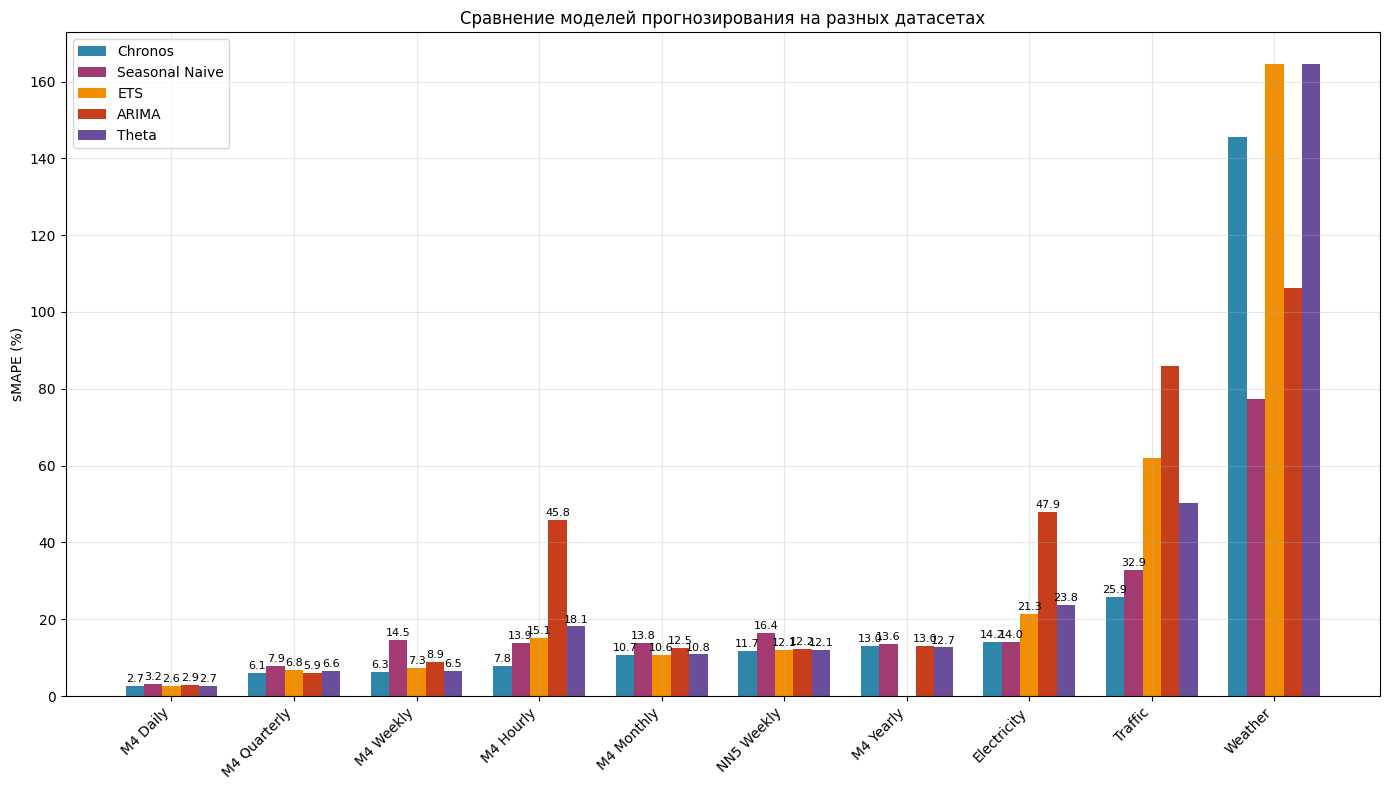

In [12]:
comparison_df.to_csv("full_model_comparison.csv", index=False)

fig, ax = plt.subplots(figsize=(14, 8))

datasets = comparison_df['Dataset'].tolist()
x = np.arange(len(datasets))
width = 0.15

models = ['Chronos', 'Seasonal Naive', 'ETS', 'ARIMA', 'Theta']
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A4E9B']
offsets = [-2*width, -width, 0, width, 2*width]

for i, (model, color, offset) in enumerate(zip(models, colors, offsets)):
    values = comparison_df[model].values
    bars = ax.bar(x + offset, values, width, label=model, color=color)

    for bar, val in zip(bars, values):
        if not np.isnan(val) and val < 50:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f'{val:.1f}', ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(datasets, rotation=45, ha='right')
ax.set_ylabel('sMAPE (%)')
ax.set_title('Сравнение моделей прогнозирования на разных датасетах')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("full_model_comparison.png", dpi=150)
plt.show()